# Code-Capacity Performance On Half-Stabilizer Errors

This notebook compares four native decoder models on a deterministic code-capacity error set.

Experiment convention:
- choose a CSS code from a `.npz` file containing `Hx`, `Hz`, `Lx`, `Lz`
- use each even-weight row of `Hx` only to define an `X`-error support
- enumerate all half-subsets of that support
- inject `X` error on each half-subset, including both complementary halves separately
- compute syndrome with `Hz`
- decode with `Hz`
- evaluate logical success using `Lz`

The four decoder families are:
- vanilla BP
- Mem-BP with one shared coefficient
- Mem-BP with random positive coefficients
- Mem-BP with random signed coefficients

For the disorder models, the notebook averages over `random_coefficient_seed_offsets` coefficient realizations per error pattern.

In [1]:
from itertools import combinations
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import relay_bp

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=160, suppress=True)

In [2]:
CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}

selected_code = "surface13"  # change here to switch code
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.10
max_iter = 40
alpha = 1.0
same_memory_coefficient = 0.15
random_positive_range = (0.0, 0.30)
random_signed_range = (-0.30, 0.30)
memory_application_scope = "stabilizer_support"  # options: "stabilizer_support", "all_bits"
base_disorder_seed = 0
random_coefficient_seed_offsets = [0, 1, 2]

DECODER_SPECS = {
    "bp": {
        "label": "Vanilla BP",
        "coeff_seed_offsets": [0],
    },
    "mem_same": {
        "label": "Mem-BP / same coefficient",
        "coeff_seed_offsets": [0],
    },
    "mem_positive_random": {
        "label": "Mem-BP / random positive disorder",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
    "mem_signed_random": {
        "label": "Mem-BP / random signed disorder",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
}

In [3]:
def load_css_code(path: Path) -> dict[str, np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return {key: np.asarray(data[key], dtype=np.uint8) % 2 for key in ["Hx", "Hz", "Lx", "Lz"]}


def stabilizer_statistics(hx: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = hx.sum(axis=1).astype(int)
    unique_weights, counts = np.unique(weights, return_counts=True)

    rows = []
    total_raw_half_subsets = 0
    total_even_weight_stabilizers = 0

    for weight, count in zip(unique_weights, counts):
        weight = int(weight)
        count = int(count)
        is_even = weight > 0 and weight % 2 == 0
        raw_half_subsets_per_row = comb(weight, weight // 2) if is_even else 0
        total_raw = count * raw_half_subsets_per_row
        if is_even:
            total_raw_half_subsets += total_raw
            total_even_weight_stabilizers += count
        rows.append({
            "row_weight": weight,
            "n_x_stabilizers": count,
            "is_even_weight": is_even,
            "raw_half_subsets_per_row": raw_half_subsets_per_row,
            "total_raw_half_subsets": total_raw,
        })

    summary = pd.DataFrame([{
        "code": selected_code,
        "Hx_rows": int(hx.shape[0]),
        "n_qubits": int(hx.shape[1]),
        "even_weight_x_stabilizers": total_even_weight_stabilizers,
        "total_half_flip_patterns": total_raw_half_subsets,
    }])

    return pd.DataFrame(rows), summary


def all_half_subsets(support_bits: list[int]) -> list[tuple[int, ...]]:
    support_bits = tuple(sorted(int(bit) for bit in support_bits))
    if len(support_bits) == 0 or len(support_bits) % 2 != 0:
        return []
    half_weight = len(support_bits) // 2
    return [tuple(sorted(subset)) for subset in combinations(support_bits, half_weight)]


def enumerate_half_stabilizer_cases(hx: np.ndarray, hz: np.ndarray) -> list[dict[str, object]]:
    cases = []
    case_id = 0
    for row_idx in range(hx.shape[0]):
        support_bits = np.flatnonzero(hx[row_idx]).astype(int).tolist()
        if len(support_bits) == 0 or len(support_bits) % 2 != 0:
            continue
        for partition_idx, flipped_bits in enumerate(all_half_subsets(support_bits)):
            error = np.zeros(hz.shape[1], dtype=np.uint8)
            error[list(flipped_bits)] = 1
            syndrome = np.asarray((hz @ error) % 2, dtype=np.uint8).reshape(-1)
            cases.append({
                "case_id": case_id,
                "row_idx": row_idx,
                "row_weight": len(support_bits),
                "half_subset_idx": partition_idx,
                "support_bits": tuple(support_bits),
                "flipped_bits": tuple(int(bit) for bit in flipped_bits),
                "error": error,
                "syndrome": syndrome,
                "syndrome_weight": int(syndrome.sum()),
            })
            case_id += 1
    return cases


def get_memory_target_indices(n_bits: int, support_bits: tuple[int, ...]) -> np.ndarray:
    if memory_application_scope == "stabilizer_support":
        return np.asarray(support_bits, dtype=int)
    if memory_application_scope == "all_bits":
        return np.arange(n_bits, dtype=int)
    raise ValueError(f"Unsupported memory_application_scope: {memory_application_scope}")


def build_memory_strengths(decoder_kind: str, n_bits: int, support_bits: tuple[int, ...], coeff_seed: int) -> np.ndarray | None:
    if decoder_kind == "bp":
        return None

    target_indices = get_memory_target_indices(n_bits, support_bits)
    strengths = np.zeros(n_bits, dtype=np.float64)

    if decoder_kind == "mem_same":
        strengths[target_indices] = same_memory_coefficient
        return strengths

    rng = np.random.default_rng(coeff_seed)
    if decoder_kind == "mem_positive_random":
        strengths[target_indices] = rng.uniform(random_positive_range[0], random_positive_range[1], size=target_indices.size)
        return strengths

    if decoder_kind == "mem_signed_random":
        strengths[target_indices] = rng.uniform(random_signed_range[0], random_signed_range[1], size=target_indices.size)
        return strengths

    raise ValueError(f"Unsupported decoder kind: {decoder_kind}")


def make_tracer(decoder_kind: str, check_matrix, error_priors: np.ndarray):
    gamma0 = None if decoder_kind == "bp" else 0.0
    return relay_bp.MinSumBPDecoderTraceF64(
        check_matrix,
        error_priors=error_priors,
        max_iter=max_iter,
        alpha=alpha,
        gamma0=gamma0,
    )


def decode_case_with_tracer(tracer, syndrome: np.ndarray, memory_strengths: np.ndarray | None):
    tracer.reset()
    if memory_strengths is not None:
        tracer.set_memory_strengths(memory_strengths)
    result = tracer.snapshot(syndrome)
    while tracer.current_iteration < max_iter and not result.success:
        result = tracer.run_iteration(syndrome)
    return result


def evaluate_decoder(decoder_kind: str, cases: list[dict[str, object]], check_matrix, lz: np.ndarray) -> pd.DataFrame:
    spec = DECODER_SPECS[decoder_kind]
    error_priors = np.full(check_matrix.shape[1], prior_error_rate, dtype=np.float64)
    tracer = make_tracer(decoder_kind, check_matrix, error_priors)
    rows = []

    for case in cases:
        for coeff_seed_offset in spec["coeff_seed_offsets"]:
            coeff_seed = base_disorder_seed + (10_000 * coeff_seed_offset) + int(case["case_id"])
            memory_strengths = build_memory_strengths(
                decoder_kind,
                check_matrix.shape[1],
                case["support_bits"],
                coeff_seed,
            )
            result = decode_case_with_tracer(tracer, case["syndrome"], memory_strengths)
            decoding = np.asarray(result.decoding, dtype=np.uint8)
            residual = np.bitwise_xor(decoding, case["error"])
            logical_signature = np.asarray((lz @ residual) % 2, dtype=np.uint8).reshape(-1)
            logical_success = bool(np.all(logical_signature == 0))
            exact_recovery = bool(np.array_equal(decoding, case["error"]))
            rows.append({
                "decoder_kind": decoder_kind,
                "decoder_label": spec["label"],
                "case_id": int(case["case_id"]),
                "row_idx": int(case["row_idx"]),
                "row_weight": int(case["row_weight"]),
                "half_subset_idx": int(case["half_subset_idx"]),
                "support_bits": list(case["support_bits"]),
                "flipped_bits": list(case["flipped_bits"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "coeff_seed_offset": int(coeff_seed_offset),
                "coeff_seed": int(coeff_seed),
                "converged": bool(result.success),
                "logical_success": logical_success,
                "exact_recovery": exact_recovery,
                "iterations": int(result.iterations),
            })

    return pd.DataFrame(rows)


def summarize_results(results_df: pd.DataFrame, n_unique_cases: int) -> pd.DataFrame:
    converged_mask = results_df["converged"].to_numpy(dtype=bool)
    logical_mask = results_df["logical_success"].to_numpy(dtype=bool)
    return pd.DataFrame([{
        "decoder": results_df["decoder_label"].iloc[0],
        "half_flip_patterns": n_unique_cases,
        "coefficient_repeats": int(results_df["coeff_seed_offset"].nunique()),
        "evaluations": int(len(results_df)),
        "convergence_rate": float(results_df["converged"].mean()),
        "logical_success_rate": float(results_df["logical_success"].mean()),
        "exact_recovery_rate": float(results_df["exact_recovery"].mean()),
        "logical_success_given_converged": float(results_df.loc[results_df["converged"], "logical_success"].mean()) if converged_mask.any() else np.nan,
        "mean_iterations": float(results_df["iterations"].mean()),
        "max_iterations_reached_rate": float((results_df["iterations"] >= max_iter).mean()),
    }])


def summarize_by_row_weight(results_df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        results_df.groupby("row_weight", as_index=False)
        .agg(
            evaluations=("case_id", "size"),
            half_flip_patterns=("case_id", "nunique"),
            convergence_rate=("converged", "mean"),
            logical_success_rate=("logical_success", "mean"),
            exact_recovery_rate=("exact_recovery", "mean"),
            mean_iterations=("iterations", "mean"),
        )
        .sort_values("row_weight")
        .reset_index(drop=True)
    )
    return grouped


def category_table(results_df: pd.DataFrame) -> pd.DataFrame:
    labels = []
    for converged, logical_success in zip(results_df["converged"], results_df["logical_success"]):
        if converged and logical_success:
            labels.append("converged / logical success")
        elif converged and not logical_success:
            labels.append("converged / logical fail")
        elif (not converged) and logical_success:
            labels.append("not converged / logical success")
        else:
            labels.append("not converged / logical fail")
    counts = pd.Series(labels).value_counts().rename_axis("category").reset_index(name="count")
    counts["rate"] = counts["count"] / len(results_df)
    return counts


def plot_decoder_results(results_df: pd.DataFrame):
    grouped = summarize_by_row_weight(results_df)
    categories = category_table(results_df)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

    x = np.arange(len(grouped))
    width = 0.24
    axes[0].bar(x - width, grouped["convergence_rate"], width=width, label="convergence")
    axes[0].bar(x, grouped["logical_success_rate"], width=width, label="logical success")
    axes[0].bar(x + width, grouped["exact_recovery_rate"], width=width, label="exact recovery")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(grouped["row_weight"].astype(str).tolist())
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_xlabel("X stabilizer row weight")
    axes[0].set_ylabel("rate")
    axes[0].set_title("Rates by stabilizer weight")
    axes[0].legend()

    axes[1].bar(categories["category"], categories["rate"], color=["#4daf4a", "#ff7f00", "#377eb8", "#e41a1c"])
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_ylabel("rate")
    axes[1].set_title("Convergence / logical-success categories")
    axes[1].tick_params(axis="x", rotation=20)

    fig.suptitle(
        f"{results_df['decoder_label'].iloc[0]} | code = {selected_code} | memory scope = {memory_application_scope}",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()
    return fig


code_data = load_css_code(npz_path)
hz_check_matrix = sparse.csc_matrix(code_data["Hz"].astype(np.uint8))
lz_matrix = code_data["Lz"].astype(np.uint8)
all_cases = enumerate_half_stabilizer_cases(code_data["Hx"], code_data["Hz"])
weight_table, stabilizer_summary = stabilizer_statistics(code_data["Hx"])

display(
    pd.DataFrame([
        {
            "code": selected_code,
            "npz_path": str(npz_path),
            "Hx_shape": code_data["Hx"].shape,
            "Hz_shape": code_data["Hz"].shape,
            "Lx_shape": code_data["Lx"].shape,
            "Lz_shape": code_data["Lz"].shape,
            "prior_error_rate": prior_error_rate,
            "max_iter": max_iter,
            "same_memory_coefficient": same_memory_coefficient,
            "random_positive_range": random_positive_range,
            "random_signed_range": random_signed_range,
            "memory_application_scope": memory_application_scope,
            "random_coefficient_seed_offsets": random_coefficient_seed_offsets,
            "enumerated_half_partitions": len(all_cases),
        }
    ])
)

,code,npz_path,Hx_shape,Hz_shape,Lx_shape,Lz_shape,prior_error_rate,max_iter,same_memory_coefficient,random_positive_range,random_signed_range,memory_application_scope,random_coefficient_seed_offsets,enumerated_half_partitions
0,surface13,C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz,"(156, 313)","(156, 313)","(1, 313)","(1, 313)",0.1,40,0.15,"(0.0, 0.3)","(-0.3, 0.3)",stabilizer_support,"[0, 1, 2]",792


## Half-Stabilizer Error Set Statistics

The next cell reports:
- the total number of `X` stabilizer generators (`Hx` rows)
- how many rows have each support size
- for even-weight rows, how many half-subsets they induce

This notebook **simulates all half-subsets**, so complementary halves are treated as distinct error patterns.

In [4]:
display(stabilizer_summary)
display(weight_table)

,code,Hx_rows,n_qubits,even_weight_x_stabilizers,total_half_flip_patterns
0,surface13,156,313,132,792


,row_weight,n_x_stabilizers,is_even_weight,raw_half_subsets_per_row,total_raw_half_subsets
0,3,24,False,0,0
1,4,132,True,6,792


## Decoder Cells

Each cell below evaluates one decoder family on the full deterministic half-subset catalogue for the currently selected code.

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Vanilla BP,792,1,792,0.060606,1.0,0.030303,1.0,37.575758,0.939394


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,792,792,0.060606,1.0,0.030303,37.575758


,category,count,rate
0,not converged / logical success,744,0.939394
1,converged / logical success,48,0.060606


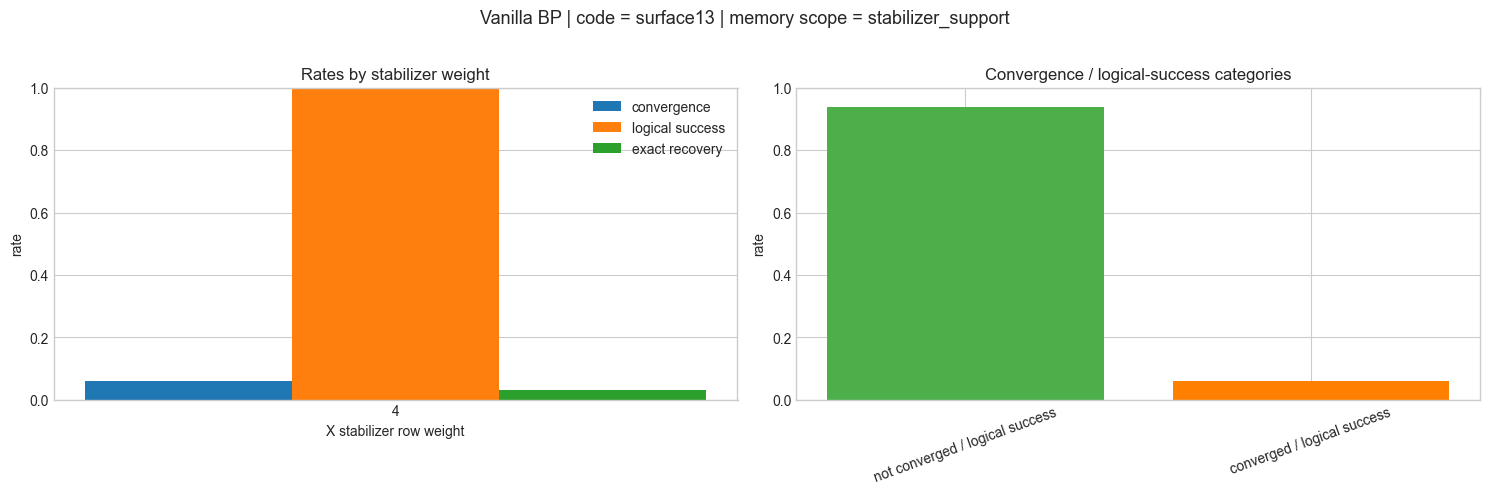

In [5]:
results_bp = evaluate_decoder("bp", all_cases, hz_check_matrix, lz_matrix)
overall_bp = summarize_results(results_bp, len(all_cases))
by_weight_bp = summarize_by_row_weight(results_bp)
categories_bp = category_table(results_bp)
display(overall_bp)
display(by_weight_bp)
display(categories_bp)
plot_decoder_results(results_bp);
plt.show()

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Mem-BP / same coefficient,792,1,792,0.010101,1.0,0.005051,1.0,39.724747,0.989899


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,792,792,0.010101,1.0,0.005051,39.724747


,category,count,rate
0,not converged / logical success,784,0.989899
1,converged / logical success,8,0.010101


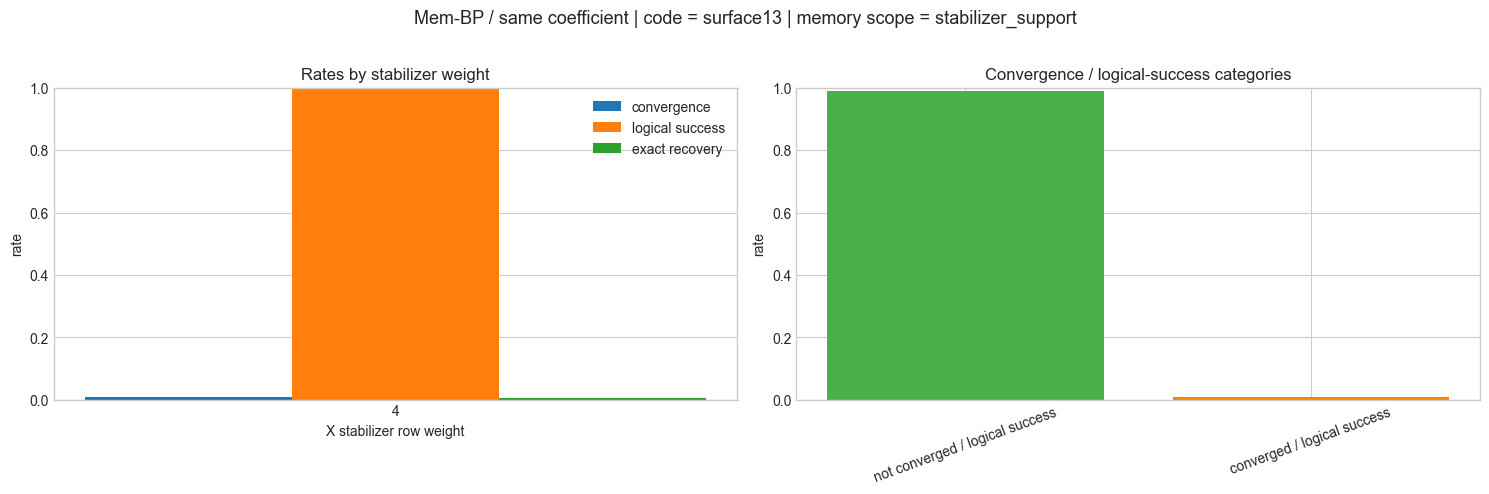

In [6]:
results_mem_same = evaluate_decoder("mem_same", all_cases, hz_check_matrix, lz_matrix)
overall_mem_same = summarize_results(results_mem_same, len(all_cases))
by_weight_mem_same = summarize_by_row_weight(results_mem_same)
categories_mem_same = category_table(results_mem_same)
display(overall_mem_same)
display(by_weight_mem_same)
display(categories_mem_same)
plot_decoder_results(results_mem_same);
plt.show()

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Mem-BP / random positive disorder,792,3,2376,1.0,1.0,0.520202,1.0,2.276515,0.0


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,2376,792,1.0,1.0,0.520202,2.276515


,category,count,rate
0,converged / logical success,2376,1.0


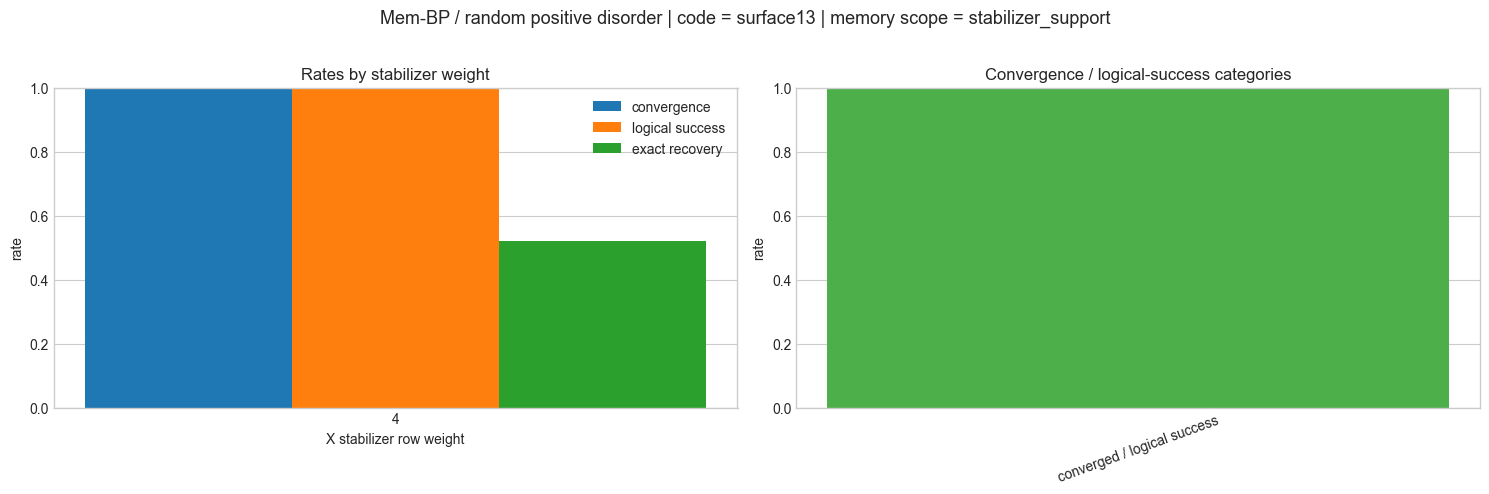

In [7]:
results_mem_positive_random = evaluate_decoder("mem_positive_random", all_cases, hz_check_matrix, lz_matrix)
overall_mem_positive_random = summarize_results(results_mem_positive_random, len(all_cases))
by_weight_mem_positive_random = summarize_by_row_weight(results_mem_positive_random)
categories_mem_positive_random = category_table(results_mem_positive_random)
display(overall_mem_positive_random)
display(by_weight_mem_positive_random)
display(categories_mem_positive_random)
plot_decoder_results(results_mem_positive_random);
plt.show()

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Mem-BP / random signed disorder,792,3,2376,0.896886,0.999158,0.458754,1.0,6.680556,0.103535


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,2376,792,0.896886,0.999158,0.458754,6.680556


,category,count,rate
0,converged / logical success,2131,0.896886
1,not converged / logical success,243,0.102273
2,not converged / logical fail,2,0.000842


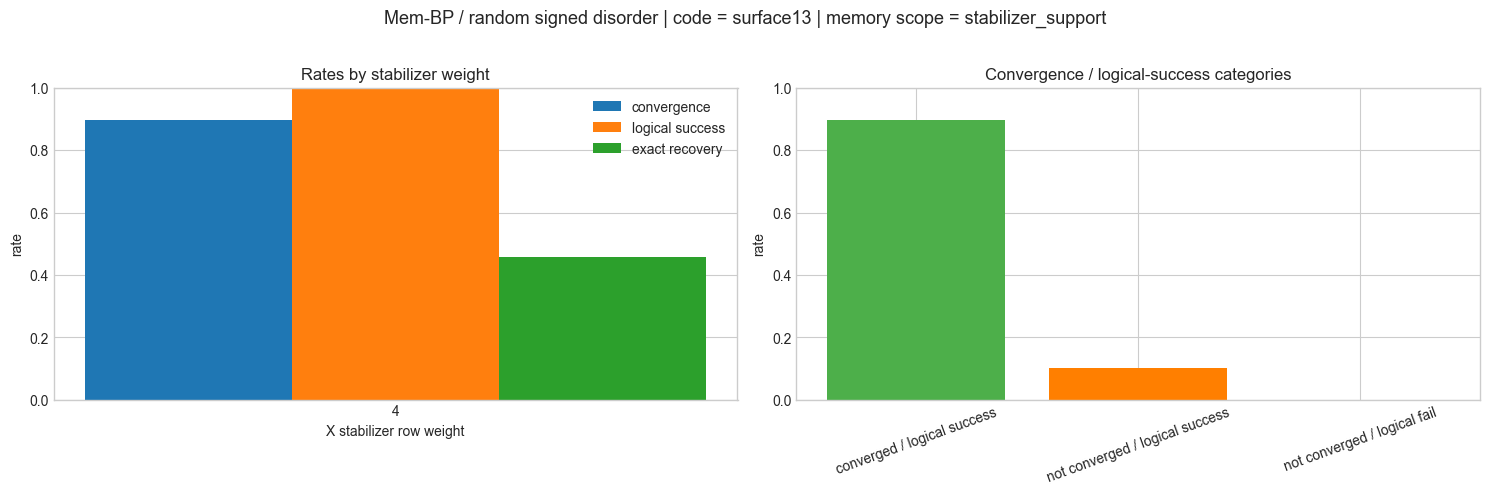

In [8]:
results_mem_signed_random = evaluate_decoder("mem_signed_random", all_cases, hz_check_matrix, lz_matrix)
overall_mem_signed_random = summarize_results(results_mem_signed_random, len(all_cases))
by_weight_mem_signed_random = summarize_by_row_weight(results_mem_signed_random)
categories_mem_signed_random = category_table(results_mem_signed_random)
display(overall_mem_signed_random)
display(by_weight_mem_signed_random)
display(categories_mem_signed_random)
plot_decoder_results(results_mem_signed_random);
plt.show()